<a href="https://colab.research.google.com/github/rodrigorissettoterra/ai-model-studies/blob/main/007_time_series_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estudo 007 — Time Series Forecasting

## Modelos estatísticos, Machine Learning e LSTM para previsão temporal

**Área:** Machine Learning / Deep Learning  
**Tipo de problema:** Forecasting univariado de séries temporais

### Pergunta de estudo

> Modelos mais sofisticados realmente melhoram a previsão de uma série temporal quando comparados a baselines simples e sazonais?

Este estudo compara cinco estratégias com complexidade crescente:

1. **Naive Forecast** — repete o último valor conhecido;
2. **Seasonal Naive** — repete o padrão observado 12 meses antes;
3. **SARIMA** — modelo estatístico com componentes autorregressivos, diferenciação e sazonalidade;
4. **HistGradientBoosting** — Machine Learning supervisionado usando lags e estatísticas temporais;
5. **LSTM** — rede neural recorrente treinada sobre sequências temporais.

### Métricas

- MAE — Mean Absolute Error;
- RMSE — Root Mean Squared Error;
- MAPE — Mean Absolute Percentage Error.

### Princípio metodológico

Em séries temporais, a ordem das observações é parte do problema.

Por isso:

- **não há `shuffle`**;
- treino, validação e teste respeitam a ordem cronológica;
- o conjunto de teste não participa da escolha de hiperparâmetros;
- previsões recursivas usam previsões anteriores quando o valor real futuro ainda não estaria disponível.


## 1. Configuração do ambiente

As sementes aleatórias são fixadas para aumentar a reprodutibilidade.

Este notebook pode ser executado em CPU, mas a etapa da LSTM pode se beneficiar de GPU.


In [1]:
# Importações gerais.
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import tensorflow as tf

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)
from sklearn.preprocessing import MinMaxScaler

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

warnings.filterwarnings("ignore")

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Statsmodels:", sm.__version__)
print("TensorFlow:", tf.__version__)
print("GPU disponível:", bool(tf.config.list_physical_devices("GPU")))


NumPy: 2.0.2
Pandas: 2.2.2
Statsmodels: 0.14.6
TensorFlow: 2.20.0
GPU disponível: True


## 2. Dataset — CO₂ atmosférico em Mauna Loa

O `statsmodels` disponibiliza uma série histórica de concentrações atmosféricas de CO₂ medidas no observatório de Mauna Loa, no Havaí.

Os dados originais são semanais. Para este estudo:

1. a série é agregada por mês;
2. eventuais lacunas são interpoladas temporalmente;
3. a frequência mensal é mantida explicitamente.

A série é adequada ao estudo porque apresenta:

- tendência de longo prazo;
- sazonalidade anual;
- dependência temporal.


In [2]:
# Carrega a série semanal de CO₂ incluída no statsmodels.
co2_weekly = sm.datasets.co2.load_pandas().data["co2"].copy()

# Agrega para frequência mensal e interpola eventuais lacunas.
series = (
    co2_weekly
    .resample("ME")
    .mean()
    .interpolate(method="time")
    .astype("float32")
)

series.name = "co2"

print(f"Observações mensais: {len(series):,}")
print(f"Início: {series.index.min().date()}")
print(f"Fim: {series.index.max().date()}")
print(f"Valores ausentes: {series.isna().sum()}")

display(series.head())
display(series.describe().to_frame("CO₂ (ppmv)"))


Observações mensais: 526
Início: 1958-03-31
Fim: 2001-12-31
Valores ausentes: 0


,co2
1958-03-31,316.100006
1958-04-30,317.200012
1958-05-31,317.433319
1958-06-30,316.543976
1958-07-31,315.625000


,CO₂ (ppmv)
count,526.000000
mean,339.619141
std,17.116529
min,313.399994
25%,324.024994
50%,337.912491
75%,354.537498
max,373.799988


## 3. Visualização da série

Antes de modelar, é importante observar a estrutura temporal.

A série completa permite identificar visualmente tendência e oscilações sazonais.


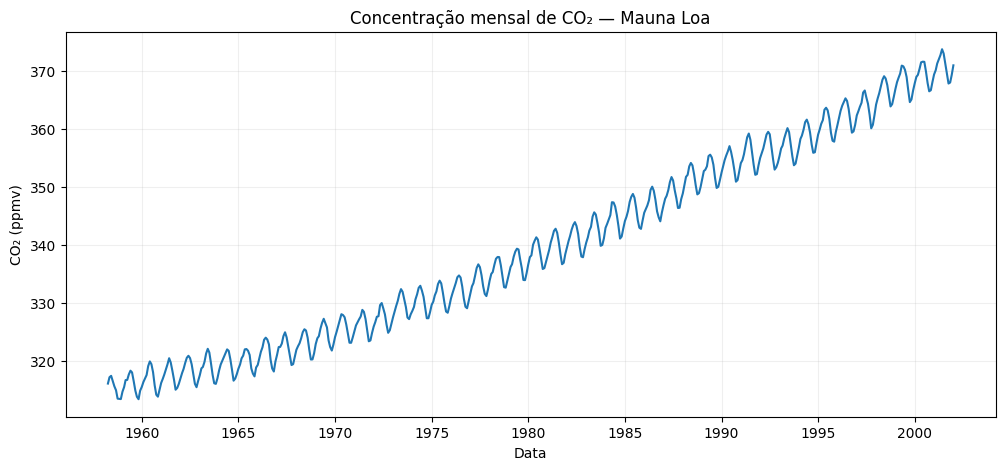

In [3]:
plt.figure(figsize=(12, 5))
plt.plot(series.index, series.values)
plt.title("Concentração mensal de CO₂ — Mauna Loa")
plt.xlabel("Data")
plt.ylabel("CO₂ (ppmv)")
plt.grid(alpha=0.2)
plt.show()


## 4. Decomposição de tendência e sazonalidade

A decomposição STL separa aproximadamente a série em:

- tendência;
- componente sazonal;
- resíduo.

Como os dados foram agregados mensalmente, utiliza-se período sazonal igual a **12 meses**.


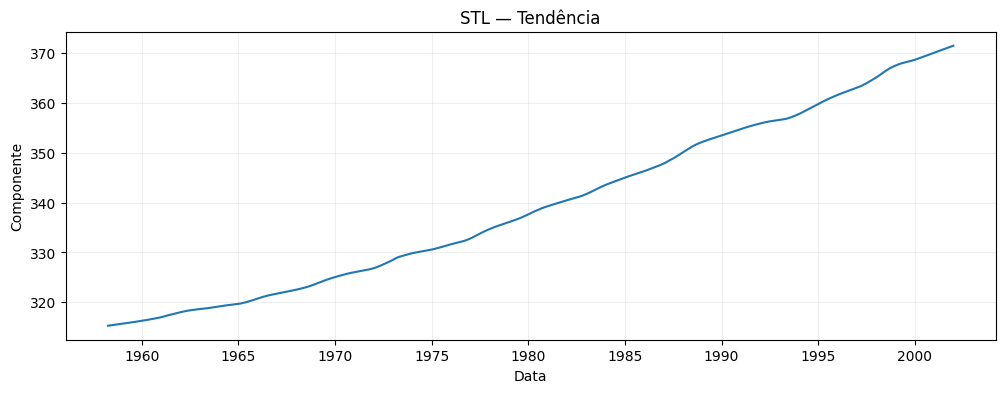

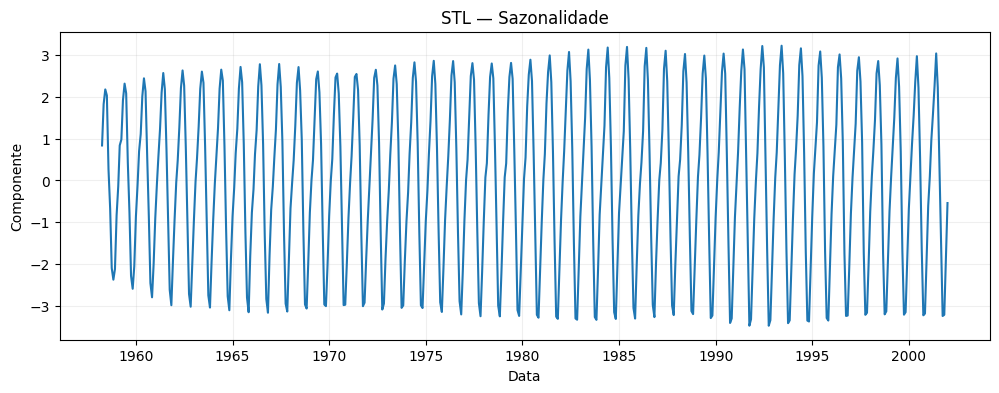

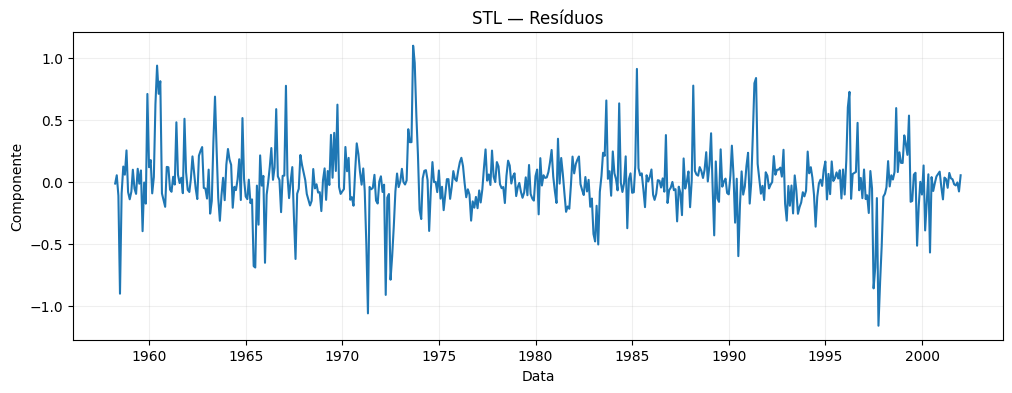

In [4]:
stl = STL(series, period=12, robust=True)
stl_result = stl.fit()

plt.figure(figsize=(12, 4))
plt.plot(stl_result.trend.index, stl_result.trend.values)
plt.title("STL — Tendência")
plt.xlabel("Data")
plt.ylabel("Componente")
plt.grid(alpha=0.2)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(stl_result.seasonal.index, stl_result.seasonal.values)
plt.title("STL — Sazonalidade")
plt.xlabel("Data")
plt.ylabel("Componente")
plt.grid(alpha=0.2)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(stl_result.resid.index, stl_result.resid.values)
plt.title("STL — Resíduos")
plt.xlabel("Data")
plt.ylabel("Componente")
plt.grid(alpha=0.2)
plt.show()


## 5. Divisão cronológica: treino, validação e teste

A divisão segue a ordem do tempo:

- **70% treino**;
- **15% validação**;
- **15% teste**.

A validação é usada para decisões de modelagem.

Depois dessas decisões, os modelos finais podem ser ajustados novamente com todo o histórico disponível antes do teste (**treino + validação**).


In [5]:
n = len(series)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train = series.iloc[:train_end]
validation = series.iloc[train_end:val_end]
test = series.iloc[val_end:]

development = series.iloc[:val_end]

split_summary = pd.DataFrame({
    "Conjunto": ["Treino", "Validação", "Teste"],
    "Observações": [len(train), len(validation), len(test)],
    "Início": [
        train.index.min().date(),
        validation.index.min().date(),
        test.index.min().date(),
    ],
    "Fim": [
        train.index.max().date(),
        validation.index.max().date(),
        test.index.max().date(),
    ],
})

display(split_summary)


,Conjunto,Observações,Início,Fim
0,Treino,368,1958-03-31,1988-10-31
1,Validação,79,1988-11-30,1995-05-31
2,Teste,79,1995-06-30,2001-12-31


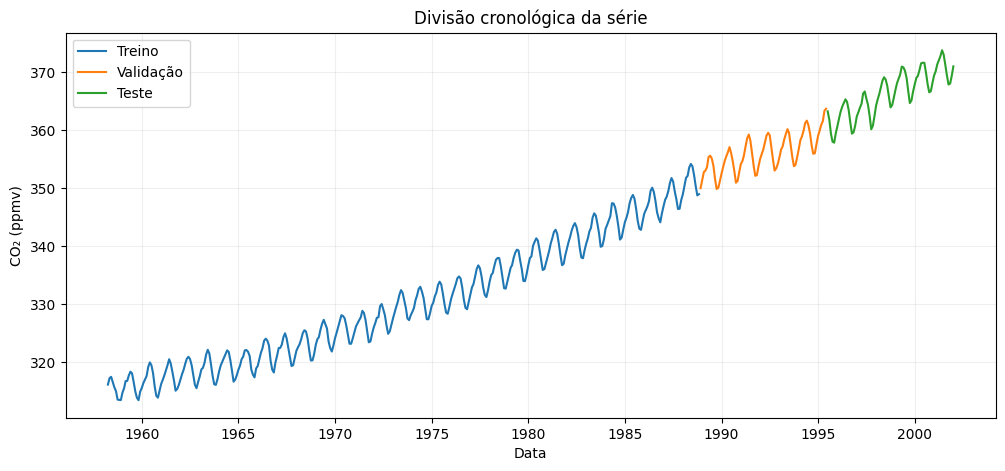

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(train.index, train.values, label="Treino")
plt.plot(validation.index, validation.values, label="Validação")
plt.plot(test.index, test.values, label="Teste")
plt.title("Divisão cronológica da série")
plt.xlabel("Data")
plt.ylabel("CO₂ (ppmv)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## 6. Funções de avaliação

As métricas serão calculadas sempre sobre o mesmo horizonte.

### MAE

Erro absoluto médio. É simples de interpretar na unidade original da série.

### RMSE

Penaliza erros grandes de maneira mais intensa.

### MAPE

Expressa o erro percentual absoluto médio.

Como os valores de CO₂ estão muito acima de zero, o MAPE pode ser utilizado sem o problema de divisão por valores próximos de zero.


In [7]:
def forecasting_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "MAPE (%)": mean_absolute_percentage_error(y_true, y_pred) * 100,
    }


def evaluate_forecast(name, y_true, y_pred):
    metrics = forecasting_metrics(y_true, y_pred)
    return {
        "Modelo": name,
        **metrics,
    }


# Parte A — Seleção e comparação na validação

Os primeiros experimentos são feitos apenas com:

- treino;
- validação.

O teste permanece intocado.


## 7. Baseline 1 — Naive Forecast

O modelo ingênuo prevê que todos os valores futuros serão iguais ao último valor observado no treinamento.

Apesar de extremamente simples, ele estabelece uma referência mínima.


In [8]:
naive_val_predictions = np.repeat(
    train.iloc[-1],
    len(validation),
)

naive_val_metrics = evaluate_forecast(
    "Naive",
    validation.values,
    naive_val_predictions,
)

display(pd.DataFrame([naive_val_metrics]).set_index("Modelo").round(4))


,MAE,RMSE,MAPE (%)
Modelo,,,
Naive,7.0915,7.7771,1.9838


## 8. Baseline 2 — Seasonal Naive

O baseline sazonal prevê que cada mês será semelhante ao mesmo mês do ciclo anterior.

Como o horizonte de validação é maior do que um ciclo, a previsão é feita recursivamente: valores previstos passam a compor o histórico disponível para previsões posteriores.


In [9]:
SEASONAL_PERIOD = 12

def seasonal_naive_recursive(history, horizon, seasonal_period=12):
    history_values = list(np.asarray(history, dtype=float))
    predictions = []

    for _ in range(horizon):
        prediction = history_values[-seasonal_period]
        predictions.append(prediction)
        history_values.append(prediction)

    return np.asarray(predictions)

seasonal_val_predictions = seasonal_naive_recursive(
    train.values,
    horizon=len(validation),
    seasonal_period=SEASONAL_PERIOD,
)

seasonal_val_metrics = evaluate_forecast(
    "Seasonal Naive",
    validation.values,
    seasonal_val_predictions,
)

display(pd.DataFrame([seasonal_val_metrics]).set_index("Modelo").round(4))


,MAE,RMSE,MAPE (%)
Modelo,,,
Seasonal Naive,4.9602,5.4997,1.3887


## 9. Modelo estatístico — SARIMA

SARIMA estende modelos ARIMA com uma estrutura sazonal.

A configuração utilizada neste estudo é:

- componente não sazonal: `(1, 1, 1)`;
- componente sazonal: `(1, 1, 1, 12)`.

O objetivo aqui não é encontrar a parametrização perfeita, mas estabelecer uma comparação consistente entre uma abordagem estatística sazonal e modelos de aprendizado de máquina.


In [10]:
sarima_val_model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
)

sarima_val_fit = sarima_val_model.fit(disp=False)

sarima_val_predictions = sarima_val_fit.forecast(
    steps=len(validation)
).to_numpy()

sarima_val_metrics = evaluate_forecast(
    "SARIMA",
    validation.values,
    sarima_val_predictions,
)

display(pd.DataFrame([sarima_val_metrics]).set_index("Modelo").round(4))


,MAE,RMSE,MAPE (%)
Modelo,,,
SARIMA,1.5173,1.7965,0.4251


## 10. Machine Learning — criação de atributos temporais

Para transformar forecasting em um problema supervisionado, cada observação será representada por valores anteriores da própria série.

Serão utilizadas:

- lags de 1, 2, 3, 6, 12, 13 e 24 meses;
- média móvel dos 3 meses anteriores;
- média móvel dos 6 meses anteriores;
- média móvel dos 12 meses anteriores;
- mês do ano codificado de forma cíclica com seno e cosseno.

Todas as médias móveis usam apenas valores anteriores ao instante previsto.


In [11]:
LAGS = [1, 2, 3, 6, 12, 13, 24]


def create_temporal_features(series_values, dates):
    df = pd.DataFrame(
        {"target": np.asarray(series_values, dtype=float)},
        index=pd.DatetimeIndex(dates),
    )

    for lag in LAGS:
        df[f"lag_{lag}"] = df["target"].shift(lag)

    shifted = df["target"].shift(1)

    df["rolling_mean_3"] = shifted.rolling(3).mean()
    df["rolling_mean_6"] = shifted.rolling(6).mean()
    df["rolling_mean_12"] = shifted.rolling(12).mean()

    month = df.index.month
    df["month_sin"] = np.sin(2 * np.pi * month / 12)
    df["month_cos"] = np.cos(2 * np.pi * month / 12)

    return df.dropna()


train_features = create_temporal_features(
    train.values,
    train.index,
)

X_train_ml = train_features.drop(columns="target")
y_train_ml = train_features["target"]

display(X_train_ml.head())
print("Amostras de treinamento supervisionado:", len(X_train_ml))


,lag_1,lag_2,lag_3,lag_6,lag_12,lag_13,lag_24,rolling_mean_3,rolling_mean_6,rolling_mean_12,month_sin,month_cos
1960-03-31,316.975006,316.380005,315.524994,313.825012,316.733337,316.700012,316.100006,316.293335,315.163335,316.096944,1.000000e+00,6.123234e-17
1960-04-30,317.575012,316.975006,316.380005,313.399994,317.674988,316.733337,317.200012,316.976674,315.788335,316.167084,8.660254e-01,-5.000000e-01
1960-05-31,319.119995,317.575012,316.975006,314.875000,318.325012,317.674988,317.433319,317.890004,316.741669,316.287501,5.000000e-01,-8.660254e-01
1960-06-30,319.924988,319.119995,317.575012,315.524994,318.024994,318.325012,316.543976,318.873332,317.583333,316.420832,1.224647e-16,-1.000000e+00
1960-07-31,319.450012,319.924988,319.119995,316.380005,316.524994,318.024994,315.625000,319.498332,318.237503,316.539584,-5.000000e-01,-8.660254e-01


Amostras de treinamento supervisionado: 344


## 11. HistGradientBoosting

O HistGradientBoosting aprende relações não lineares entre os atributos temporais e o próximo valor da série.

Para preservar a causalidade temporal, a previsão da validação é **recursiva**: após prever um mês, essa previsão é incorporada ao histórico usado para gerar os atributos do mês seguinte.


In [12]:
ml_model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=15,
    l2_regularization=0.1,
    random_state=SEED,
)

ml_model.fit(X_train_ml, y_train_ml)


HistGradientBoostingRegressor(l2_regularization=0.1, learning_rate=0.05,
                              max_iter=300, max_leaf_nodes=15, random_state=42)

In [13]:
def build_single_ml_features(history_values, next_date):
    history = pd.Series(
        np.asarray(history_values, dtype=float)
    )

    features = {}

    for lag in LAGS:
        features[f"lag_{lag}"] = history.iloc[-lag]

    features["rolling_mean_3"] = history.iloc[-3:].mean()
    features["rolling_mean_6"] = history.iloc[-6:].mean()
    features["rolling_mean_12"] = history.iloc[-12:].mean()

    month = pd.Timestamp(next_date).month
    features["month_sin"] = np.sin(2 * np.pi * month / 12)
    features["month_cos"] = np.cos(2 * np.pi * month / 12)

    return pd.DataFrame([features])


def recursive_ml_forecast(model, history, forecast_index):
    history_values = list(np.asarray(history, dtype=float))
    predictions = []

    for next_date in forecast_index:
        X_next = build_single_ml_features(
            history_values,
            next_date,
        )

        prediction = float(model.predict(X_next)[0])

        predictions.append(prediction)
        history_values.append(prediction)

    return np.asarray(predictions)


ml_val_predictions = recursive_ml_forecast(
    ml_model,
    train.values,
    validation.index,
)

ml_val_metrics = evaluate_forecast(
    "HistGradientBoosting",
    validation.values,
    ml_val_predictions,
)

display(pd.DataFrame([ml_val_metrics]).set_index("Modelo").round(4))


,MAE,RMSE,MAPE (%)
Modelo,,,
HistGradientBoosting,4.4935,5.2479,1.2555


## 12. Deep Learning — preparação das sequências para LSTM

A LSTM recebe uma janela temporal de valores anteriores e tenta prever o próximo valor.

Neste estudo:

- janela = 24 meses;
- apenas valores anteriores entram na sequência;
- o scaler é ajustado somente com o treino durante a etapa de validação.


In [14]:
WINDOW_SIZE = 24

train_scaler = MinMaxScaler()

train_scaled = train_scaler.fit_transform(
    train.to_numpy().reshape(-1, 1)
).ravel()

validation_scaled = train_scaler.transform(
    validation.to_numpy().reshape(-1, 1)
).ravel()


def create_sequences(values, window_size):
    X, y = [], []

    for i in range(window_size, len(values)):
        X.append(values[i - window_size:i])
        y.append(values[i])

    X = np.asarray(X, dtype="float32")[..., np.newaxis]
    y = np.asarray(y, dtype="float32")

    return X, y


X_train_lstm, y_train_lstm = create_sequences(
    train_scaled,
    WINDOW_SIZE,
)

# Para validar, cada sequência pode usar o histórico real já observado
# antes do início da validação, mas o alvo pertence à validação.
validation_context_scaled = np.concatenate([
    train_scaled[-WINDOW_SIZE:],
    validation_scaled,
])

X_val_lstm, y_val_lstm = create_sequences(
    validation_context_scaled,
    WINDOW_SIZE,
)

print("Treino LSTM:", X_train_lstm.shape, y_train_lstm.shape)
print("Validação LSTM:", X_val_lstm.shape, y_val_lstm.shape)


Treino LSTM: (344, 24, 1) (344,)
Validação LSTM: (79, 24, 1) (79,)


## 13. Arquitetura LSTM

A rede contém:

- uma camada LSTM;
- dropout;
- uma camada densa intermediária;
- uma saída linear para regressão.

O `EarlyStopping` usa exclusivamente a validação.


In [15]:
def build_lstm_model():
    model = Sequential([
        Input(shape=(WINDOW_SIZE, 1)),
        LSTM(32),
        Dropout(0.20),
        Dense(16, activation="relu"),
        Dense(1),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=["mae"],
    )

    return model


lstm_val_model = build_lstm_model()
lstm_val_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
)

lstm_history = lstm_val_model.fit(
    X_train_lstm,
    y_train_lstm,
    validation_data=(X_val_lstm, y_val_lstm),
    epochs=150,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=0,
)

history_df = pd.DataFrame(lstm_history.history)

best_epoch = int(history_df["val_loss"].idxmin() + 1)

print(f"Épocas executadas: {len(history_df)}")
print(f"Melhor época: {best_epoch}")
print(f"Menor validation loss: {history_df['val_loss'].min():.6f}")


Épocas executadas: 23
Melhor época: 13
Menor validation loss: 0.004102


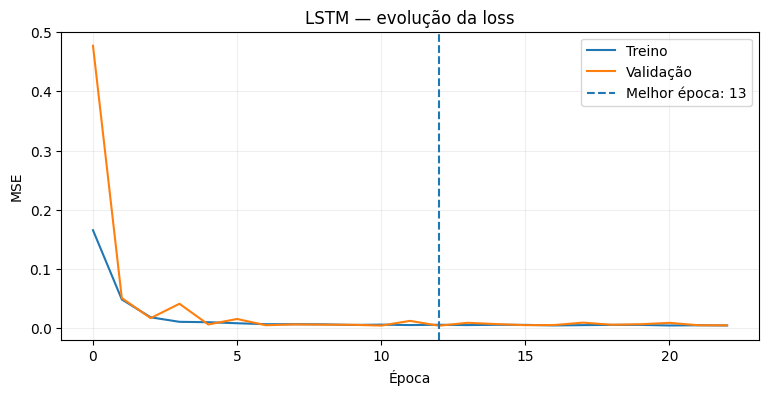

In [17]:
plt.figure(figsize=(9, 4))
plt.plot(history_df["loss"], label="Treino")
plt.plot(history_df["val_loss"], label="Validação")
plt.axvline(best_epoch - 1, linestyle="--", label=f"Melhor época: {best_epoch}")
plt.title("LSTM — evolução da loss")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## 14. Forecast recursivo da LSTM na validação

Assim como no modelo de Machine Learning, a LSTM não recebe valores reais futuros durante o forecast.

Cada previsão é adicionada à sequência e usada para produzir a previsão seguinte.


In [18]:
def recursive_lstm_forecast(
    model,
    history_values,
    scaler,
    horizon,
    window_size,
):
    scaled_history = scaler.transform(
        np.asarray(history_values).reshape(-1, 1)
    ).ravel().tolist()

    predictions_scaled = []

    for _ in range(horizon):
        window = np.asarray(
            scaled_history[-window_size:],
            dtype="float32",
        ).reshape(1, window_size, 1)

        prediction_scaled = float(
            model.predict(window, verbose=0)[0, 0]
        )

        predictions_scaled.append(prediction_scaled)
        scaled_history.append(prediction_scaled)

    predictions = scaler.inverse_transform(
        np.asarray(predictions_scaled).reshape(-1, 1)
    ).ravel()

    return predictions


lstm_val_predictions = recursive_lstm_forecast(
    lstm_val_model,
    train.values,
    train_scaler,
    horizon=len(validation),
    window_size=WINDOW_SIZE,
)

lstm_val_metrics = evaluate_forecast(
    "LSTM",
    validation.values,
    lstm_val_predictions,
)

display(pd.DataFrame([lstm_val_metrics]).set_index("Modelo").round(4))


,MAE,RMSE,MAPE (%)
Modelo,,,
LSTM,3.6766,4.4318,1.0268


## 15. Comparação na validação

Antes de tocar no teste, os cinco métodos são comparados no mesmo horizonte de validação.


In [19]:
validation_results = pd.DataFrame([
    naive_val_metrics,
    seasonal_val_metrics,
    sarima_val_metrics,
    ml_val_metrics,
    lstm_val_metrics,
]).set_index("Modelo").sort_values("RMSE")

display(validation_results.round(4))

validation_winner = validation_results["RMSE"].idxmin()

print(f"Menor RMSE na validação: {validation_winner}")


,MAE,RMSE,MAPE (%)
Modelo,,,
SARIMA,1.5173,1.7965,0.4251
LSTM,3.6766,4.4318,1.0268
HistGradientBoosting,4.4935,5.2479,1.2555
Seasonal Naive,4.9602,5.4997,1.3887
Naive,7.0915,7.7771,1.9838


Menor RMSE na validação: SARIMA


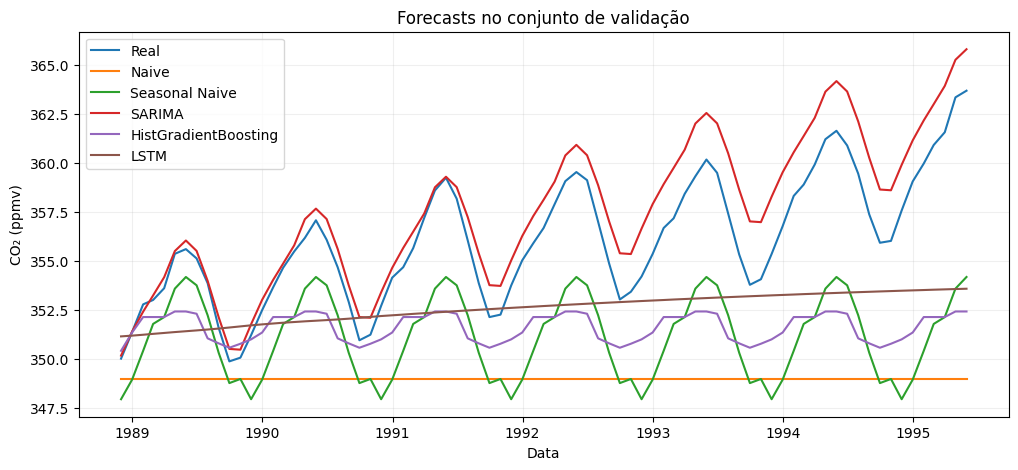

In [20]:
plt.figure(figsize=(12, 5))
plt.plot(validation.index, validation.values, label="Real")
plt.plot(validation.index, naive_val_predictions, label="Naive")
plt.plot(validation.index, seasonal_val_predictions, label="Seasonal Naive")
plt.plot(validation.index, sarima_val_predictions, label="SARIMA")
plt.plot(validation.index, ml_val_predictions, label="HistGradientBoosting")
plt.plot(validation.index, lstm_val_predictions, label="LSTM")
plt.title("Forecasts no conjunto de validação")
plt.xlabel("Data")
plt.ylabel("CO₂ (ppmv)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


# Parte B — Avaliação final no teste

Após observar a validação, os modelos são ajustados novamente utilizando todo o histórico anterior ao teste:

**treino + validação = conjunto de desenvolvimento**

O teste continua sendo um período futuro completamente separado.


## 16. Baselines finais


In [21]:
naive_test_predictions = np.repeat(
    development.iloc[-1],
    len(test),
)

seasonal_test_predictions = seasonal_naive_recursive(
    development.values,
    horizon=len(test),
    seasonal_period=SEASONAL_PERIOD,
)


## 17. SARIMA final

A mesma especificação definida anteriormente é agora ajustada ao conjunto de desenvolvimento completo.


In [22]:
sarima_test_model = SARIMAX(
    development,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
)

sarima_test_fit = sarima_test_model.fit(disp=False)

sarima_test_predictions = sarima_test_fit.forecast(
    steps=len(test)
).to_numpy()


## 18. HistGradientBoosting final

O modelo supervisionado também é treinado novamente com todos os dados disponíveis antes do teste.


In [23]:
development_features = create_temporal_features(
    development.values,
    development.index,
)

X_development_ml = development_features.drop(columns="target")
y_development_ml = development_features["target"]

ml_test_model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=15,
    l2_regularization=0.1,
    random_state=SEED,
)

ml_test_model.fit(
    X_development_ml,
    y_development_ml,
)

ml_test_predictions = recursive_ml_forecast(
    ml_test_model,
    development.values,
    test.index,
)


## 19. LSTM final

A melhor quantidade de épocas observada durante treino/validação é utilizada para retreinar uma nova LSTM com todo o conjunto de desenvolvimento.

O scaler também é ajustado novamente apenas com informações anteriores ao teste.


In [24]:
development_scaler = MinMaxScaler()

development_scaled = development_scaler.fit_transform(
    development.to_numpy().reshape(-1, 1)
).ravel()

X_development_lstm, y_development_lstm = create_sequences(
    development_scaled,
    WINDOW_SIZE,
)

tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

lstm_test_model = build_lstm_model()

lstm_test_model.fit(
    X_development_lstm,
    y_development_lstm,
    epochs=best_epoch,
    batch_size=32,
    verbose=0,
)

lstm_test_predictions = recursive_lstm_forecast(
    lstm_test_model,
    development.values,
    development_scaler,
    horizon=len(test),
    window_size=WINDOW_SIZE,
)


## 20. Resultados finais

Todos os métodos são avaliados no mesmo intervalo temporal de teste.


In [25]:
test_results = pd.DataFrame([
    evaluate_forecast(
        "Naive",
        test.values,
        naive_test_predictions,
    ),
    evaluate_forecast(
        "Seasonal Naive",
        test.values,
        seasonal_test_predictions,
    ),
    evaluate_forecast(
        "SARIMA",
        test.values,
        sarima_test_predictions,
    ),
    evaluate_forecast(
        "HistGradientBoosting",
        test.values,
        ml_test_predictions,
    ),
    evaluate_forecast(
        "LSTM",
        test.values,
        lstm_test_predictions,
    ),
]).set_index("Modelo").sort_values("RMSE")

display(test_results.round(4))

test_winner = test_results["RMSE"].idxmin()
print(f"Menor RMSE no teste: {test_winner}")


,MAE,RMSE,MAPE (%)
Modelo,,,
SARIMA,1.0326,1.2281,0.2807
Naive,3.9164,4.6712,1.0644
HistGradientBoosting,5.5678,6.5390,1.5105
Seasonal Naive,6.7745,7.5469,1.8422
LSTM,11.8149,13.0816,3.2099


Menor RMSE no teste: SARIMA


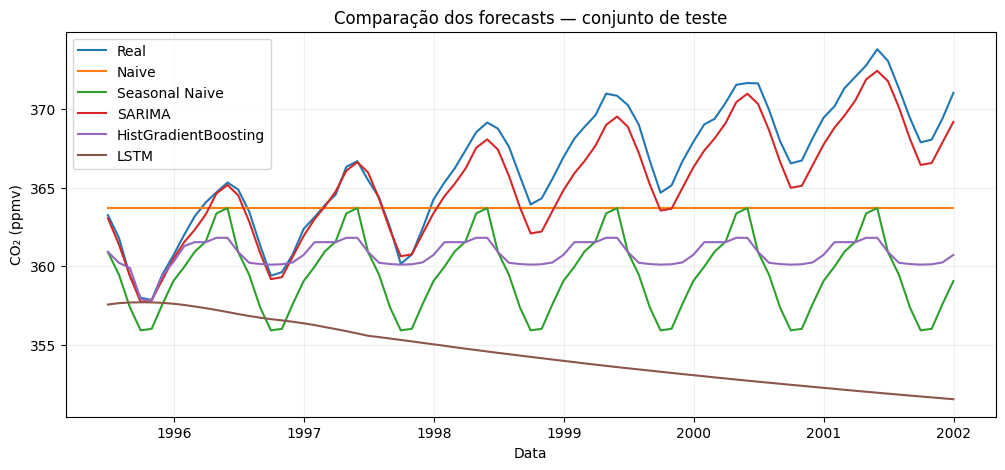

In [26]:
plt.figure(figsize=(12, 5))
plt.plot(test.index, test.values, label="Real")
plt.plot(test.index, naive_test_predictions, label="Naive")
plt.plot(test.index, seasonal_test_predictions, label="Seasonal Naive")
plt.plot(test.index, sarima_test_predictions, label="SARIMA")
plt.plot(test.index, ml_test_predictions, label="HistGradientBoosting")
plt.plot(test.index, lstm_test_predictions, label="LSTM")
plt.title("Comparação dos forecasts — conjunto de teste")
plt.xlabel("Data")
plt.ylabel("CO₂ (ppmv)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## 21. Análise do erro ao longo do horizonte

Em forecasts recursivos, erros iniciais podem se propagar para previsões posteriores.

A célula abaixo mostra o erro absoluto de cada método em função do número de meses à frente.


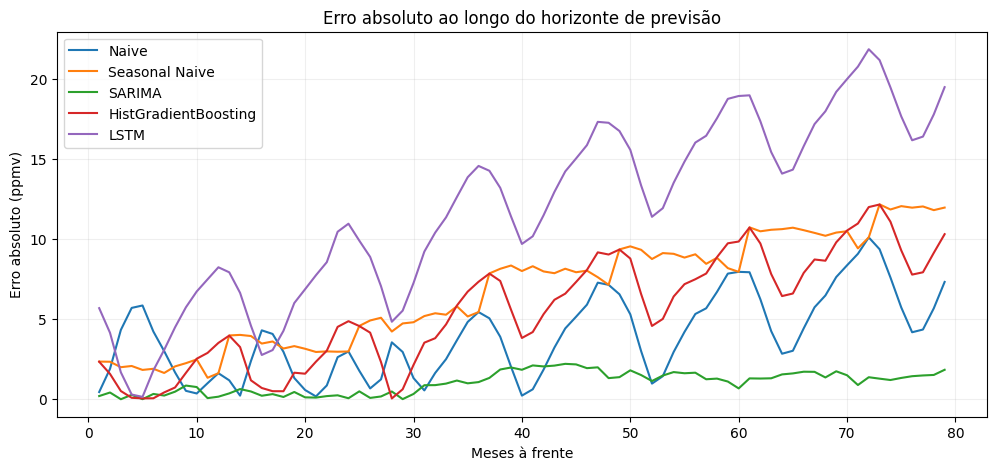

In [27]:
horizon = np.arange(1, len(test) + 1)

absolute_errors = pd.DataFrame({
    "Horizonte": horizon,
    "Naive": np.abs(test.values - naive_test_predictions),
    "Seasonal Naive": np.abs(test.values - seasonal_test_predictions),
    "SARIMA": np.abs(test.values - sarima_test_predictions),
    "HistGradientBoosting": np.abs(test.values - ml_test_predictions),
    "LSTM": np.abs(test.values - lstm_test_predictions),
})

plt.figure(figsize=(12, 5))

for model_name in [
    "Naive",
    "Seasonal Naive",
    "SARIMA",
    "HistGradientBoosting",
    "LSTM",
]:
    plt.plot(
        absolute_errors["Horizonte"],
        absolute_errors[model_name],
        label=model_name,
    )

plt.title("Erro absoluto ao longo do horizonte de previsão")
plt.xlabel("Meses à frente")
plt.ylabel("Erro absoluto (ppmv)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## 22. Comparação por horizonte

Além da métrica global, é útil separar o erro entre horizontes:

- curto prazo;
- médio prazo;
- longo prazo.

Isso ajuda a identificar modelos que funcionam bem nos primeiros passos, mas degradam quando precisam prever muitos períodos recursivamente.


In [28]:
def rmse(values):
    values = np.asarray(values, dtype=float)
    return np.sqrt(np.mean(values ** 2))


horizon_groups = []

cut_1 = min(12, len(test))
cut_2 = min(36, len(test))

for model_name in [
    "Naive",
    "Seasonal Naive",
    "SARIMA",
    "HistGradientBoosting",
    "LSTM",
]:
    errors = absolute_errors[model_name].to_numpy()

    horizon_groups.append({
        "Modelo": model_name,
        f"RMSE 1-{cut_1} meses": rmse(errors[:cut_1]),
        f"RMSE {cut_1 + 1}-{cut_2} meses": (
            rmse(errors[cut_1:cut_2])
            if cut_2 > cut_1
            else np.nan
        ),
        f"RMSE {cut_2 + 1}+ meses": (
            rmse(errors[cut_2:])
            if len(errors) > cut_2
            else np.nan
        ),
    })

horizon_results = pd.DataFrame(
    horizon_groups
).set_index("Modelo")

display(horizon_results.round(4))


,RMSE 1-12 meses,RMSE 13-36 meses,RMSE 37+ meses
Modelo,,,
Naive,3.2007,2.6880,5.7616
Seasonal Naive,2.0172,4.3134,9.6499
SARIMA,0.4097,0.5732,1.5939
HistGradientBoosting,1.7980,3.6690,8.3751
LSTM,4.8927,8.7240,16.2862


## 23. Conclusão

A conclusão abaixo é gerada automaticamente com os resultados da execução atual, evitando registrar números que não tenham sido reproduzidos.


In [29]:
from IPython.display import Markdown, display

winner = test_results["RMSE"].idxmin()

winner_mae = test_results.loc[winner, "MAE"]
winner_rmse = test_results.loc[winner, "RMSE"]
winner_mape = test_results.loc[winner, "MAPE (%)"]

naive_rmse = test_results.loc["Naive", "RMSE"]
seasonal_rmse = test_results.loc["Seasonal Naive", "RMSE"]
lstm_rmse = test_results.loc["LSTM", "RMSE"]
sarima_rmse = test_results.loc["SARIMA", "RMSE"]

improvement_vs_naive = (
    (naive_rmse - winner_rmse) / naive_rmse * 100
)

improvement_vs_seasonal = (
    (seasonal_rmse - winner_rmse) / seasonal_rmse * 100
)

lstm_vs_sarima = (
    (sarima_rmse - lstm_rmse) / sarima_rmse * 100
)

conclusion = f'''
### Síntese dos resultados

O menor RMSE no conjunto de teste foi obtido por **{winner}**.

- **MAE:** {winner_mae:.4f} ppmv
- **RMSE:** {winner_rmse:.4f} ppmv
- **MAPE:** {winner_mape:.3f}%

Em relação ao baseline Naive, o melhor modelo reduziu o RMSE em aproximadamente **{improvement_vs_naive:.1f}%**.

Em relação ao baseline Seasonal Naive, a redução foi de aproximadamente **{improvement_vs_seasonal:.1f}%**.

A diferença relativa de RMSE da LSTM em relação ao SARIMA foi de **{lstm_vs_sarima:+.1f}%**:
valor positivo indica vantagem da LSTM; valor negativo indica vantagem do SARIMA.

### O que este estudo demonstra

O ponto principal não é assumir que o modelo mais complexo será o melhor.

Em séries temporais, baselines simples podem ser difíceis de superar quando existe forte persistência ou sazonalidade.
Modelos estatísticos incorporam explicitamente hipóteses sobre a estrutura temporal, enquanto modelos de Machine Learning dependem da engenharia de atributos e redes recorrentes aprendem representações das sequências.

A comparação também evidencia a importância do **horizonte de previsão**: modelos recursivos podem acumular erro à medida que passam a depender das próprias previsões.

### Limitações

- foi analisada apenas uma série univariada;
- a parametrização do SARIMA não foi otimizada sistematicamente;
- o HistGradientBoosting utilizou um conjunto fixo de lags;
- a arquitetura da LSTM é propositalmente simples;
- não foram incorporadas variáveis externas;
- não foi aplicada avaliação walk-forward com múltiplas janelas;
- custo computacional e tempo de treinamento não foram formalmente comparados.

### Próximos experimentos

1. aplicar **walk-forward validation**;
2. otimizar ordens do SARIMA;
3. testar diferentes janelas e lags;
4. comparar XGBoost/LightGBM;
5. testar GRU e arquiteturas Transformer para séries temporais;
6. incluir variáveis exógenas;
7. avaliar intervalos de confiança e incerteza;
8. repetir o protocolo em séries de demanda de energia, vendas ou tráfego.
'''

display(Markdown(conclusion))



### Síntese dos resultados

O menor RMSE no conjunto de teste foi obtido por **SARIMA**.

- **MAE:** 1.0326 ppmv
- **RMSE:** 1.2281 ppmv
- **MAPE:** 0.281%

Em relação ao baseline Naive, o melhor modelo reduziu o RMSE em aproximadamente **73.7%**.

Em relação ao baseline Seasonal Naive, a redução foi de aproximadamente **83.7%**.

A diferença relativa de RMSE da LSTM em relação ao SARIMA foi de **-965.2%**:
valor positivo indica vantagem da LSTM; valor negativo indica vantagem do SARIMA.

### O que este estudo demonstra

O ponto principal não é assumir que o modelo mais complexo será o melhor.

Em séries temporais, baselines simples podem ser difíceis de superar quando existe forte persistência ou sazonalidade. 
Modelos estatísticos incorporam explicitamente hipóteses sobre a estrutura temporal, enquanto modelos de Machine Learning dependem da engenharia de atributos e redes recorrentes aprendem representações das sequências.

A comparação também evidencia a importância do **horizonte de previsão**: modelos recursivos podem acumular erro à medida que passam a depender das próprias previsões.

### Limitações

- foi analisada apenas uma série univariada;
- a parametrização do SARIMA não foi otimizada sistematicamente;
- o HistGradientBoosting utilizou um conjunto fixo de lags;
- a arquitetura da LSTM é propositalmente simples;
- não foram incorporadas variáveis externas;
- não foi aplicada avaliação walk-forward com múltiplas janelas;
- custo computacional e tempo de treinamento não foram formalmente comparados.

### Próximos experimentos

1. aplicar **walk-forward validation**;
2. otimizar ordens do SARIMA;
3. testar diferentes janelas e lags;
4. comparar XGBoost/LightGBM;
5. testar GRU e arquiteturas Transformer para séries temporais;
6. incluir variáveis exógenas;
7. avaliar intervalos de confiança e incerteza;
8. repetir o protocolo em séries de demanda de energia, vendas ou tráfego.


## 24. Principais aprendizados

Ao concluir este estudo, devem ficar claros quatro princípios:

### 1. Dados temporais não devem ser embaralhados

Treinar com informações futuras e testar no passado produz uma avaliação artificial.

### 2. Baselines são indispensáveis

Uma LSTM que não supera uma previsão ingênua ou sazonal adiciona complexidade sem demonstrar ganho preditivo.

### 3. Forecasting depende do horizonte

Um modelo pode ser excelente para um mês à frente e ruim para dezenas de meses.

### 4. Complexidade não garante desempenho

Modelos estatísticos simples podem superar redes neurais quando a estrutura da série é bem representada por tendência, autocorrelação e sazonalidade.


## 25. Próximo passo no repositório

Este estudo cria uma ponte entre Machine Learning tradicional, Deep Learning e problemas sequenciais.

A sequência sugerida do repositório passa a ser:

**006 — Sentiment Transformer**  
→ **007 — Time Series Forecasting**  
→ **008 — Semantic Search**

O Study 008 muda o foco de previsão para **representação vetorial e recuperação de informação**, preparando a base conceitual para estudos posteriores de RAG.


## Referências

- Statsmodels — Mauna Loa Weekly Atmospheric CO₂ Dataset;
- Statsmodels — STL decomposition;
- Statsmodels — SARIMAX;
- scikit-learn — HistGradientBoostingRegressor;
- Keras — LSTM layer.

O dataset histórico é utilizado para fins educacionais e de comparação metodológica.
